In [94]:
!pip install langgraph

In [95]:
!pip install langchain

In [96]:
!pip install google-generativeai

In [97]:
!pip install langchain-google-genai

In [98]:
!pip install dotenv

In [99]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
import os
import operator

In [100]:
load_dotenv()

True

In [101]:
model= ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [102]:
class HtmlState(TypedDict):
  HTML:str


In [103]:
def coding(state:HtmlState)->HtmlState:

  prompt = f"""
  User request: {state['HTML']}

  You are an expert frontend developer.

  Generate a complete {state['HTML']} using HTML.

  STRICT RULES:
  - Return ONLY code
  - No explanations
  - No markdown (no ```html)
  - No comments outside code
  - Output must be a SINGLE HTML file 
  - Code must start with <!DOCTYPE html>

  """
  
  output=model.invoke(prompt)

  return{"HTML":output.content}


In [104]:

graph=StateGraph(HtmlState)

graph.add_node("Coding",coding)
graph.add_edge(START,'Coding')
graph.add_edge('Coding',END)


workflow=graph.compile()




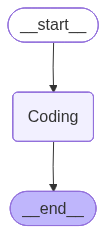

In [105]:
workflow


In [106]:
initial_state = {
    'HTML':'give html '
}

result = workflow.invoke(initial_state)

In [108]:
with open("calculator.html", "w") as f:
    f.write(result["HTML"])
